# Pregunta 7: Mapas de métricas de duración de dry spells (CR2MET vs ALADIN histórico) y delta

## Objetivo
Construir mapas para el periodo histórico común **1980–2014** de métricas de duración de **dry spells** en:

- **CR2MET** (interpolado a la grilla ALADIN)
- **ALADIN histórico** (grilla nativa)
- **Delta**: \(\Delta = \text{ALADIN} - \text{CR2MET}\)

## Tres formas de definir el umbral de día seco

### A) Opción B — umbral equivalente integrado (Pregunta 6)
- **CR2MET**: día seco si `pr < 1.0 mm/día`
- **ALADIN**: día seco si `pr < τ*_dominio` (5.285 mm/día), donde τ* iguala la **fracción integrada** de wet days en todo Chile

### B) Mismo umbral en ambos modelos
- **CR2MET y ALADIN**: día seco si `pr < 1.0 mm/día` (sin calibración)

### C) Umbral equivalente **local** (wet-day matching por píxel)
- En cada píxel: calcular \(F_{CR2MET}(\tau=1\,\text{mm})\) = % temporal de días húmedos
- Buscar \(\tau^*(x,y)\) en ALADIN tal que \(F_{ALADIN}(\tau^*) = F_{CR2MET}(1\,\text{mm})\) en ese píxel
- Generar **mapa de τ*(x,y)** y usarlo para detectar dry spells en ALADIN

## Dominio
- Máscara: **Chile continental** (Natural Earth `admin_0_countries`, 10m)
- Grilla de referencia: **ALADIN CHP12** (`y`×`x`, `lat/lon` 2D)
- **CR2MET** se interpola linealmente a esa grilla (`xarray.interp`)

## Métricas (por píxel)
- **mean**: duración promedio de dry spells (días)
- **t99**: percentil 99 de duración (días)
- **tL**: cutoff de cola (opcional; suele ser más inestable espacialmente)


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from IPython.display import display
from shapely.geometry import Point
from shapely.ops import unary_union
from shapely.prepared import prep

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = False

# =====================================================================
# CONFIGURACION
# =====================================================================
START_DATE = '1980-01-01'
END_DATE = '2014-12-31'

TAU_CR2MET_REF = 1.0  # mm/dia (referencia CR2MET en todos los enfoques)
TAU_ALADIN_DOMINIO = 5.285  # tau* integrado (Pregunta 6, Opcion B)

# Biseccion para umbrales locales (mismo criterio que Pregunta 6, pero por pixel)
BISECTION_TAU_MAX = 15.0
BISECTION_TOL = 1e-4  # fraccion 0-1

MIN_SPELLS_FOR_STATS = 30
COMPUTE_TL = False  # cambia a True si necesitas tL
CHILE_EXTENT = [-76, -65, -55, -17]
DOMAIN_MASK_RESOLUTION = '10m'


def load_chile_geometry():
    shp_path = shpreader.natural_earth(
        resolution=DOMAIN_MASK_RESOLUTION,
        category='cultural',
        name='admin_0_countries',
    )
    reader = shpreader.Reader(shp_path)
    geoms = [
        record.geometry
        for record in reader.records()
        if record.attributes.get('NAME') == 'Chile' or record.attributes.get('ADMIN') == 'Chile'
    ]
    if not geoms:
        raise RuntimeError('No se encontro Chile en Natural Earth admin_0_countries')
    return unary_union(geoms)


def build_chile_mask_on_aladin_grid(lat2d, lon2d, geometry):
    prepared = prep(geometry)
    flat_mask = np.fromiter(
        (
            prepared.contains(Point(float(x), float(y))) or geometry.touches(Point(float(x), float(y)))
            for y, x in zip(lat2d.ravel(), lon2d.ravel())
        ),
        dtype=bool,
        count=lat2d.size,
    )
    return flat_mask.reshape(lat2d.shape)


def open_aladin_historical():
    ds = xr.open_mfdataset('./pr1/pr_CHP12_*_historical_*.nc', use_cftime=True, chunks={'time': 365})
    return ds['pr'].sel(time=slice(START_DATE, END_DATE)) * 86400.0


def open_cr2met_historical():
    ds = xr.open_mfdataset('./pr/CR2MET_pr_v2.5_day_*.nc', chunks={'time': 365})
    return ds['pr'].sel(time=slice(START_DATE, END_DATE))


def regrid_cr2met_to_aladin(pr_cr2met, pr_aladin_template):
    return pr_cr2met.interp(
        lat=pr_aladin_template['lat'],
        lon=pr_aladin_template['lon'],
        method='linear',
    )


print('1/5: Cargando datos y construyendo dominio comun...')
pr_aladin = open_aladin_historical()
pr_cr2met_native = open_cr2met_historical()

chile_geom = load_chile_geometry()
chile_mask_bool = build_chile_mask_on_aladin_grid(pr_aladin['lat'].values, pr_aladin['lon'].values, chile_geom)
chile_mask = xr.DataArray(
    chile_mask_bool,
    coords={'y': pr_aladin['y'], 'x': pr_aladin['x'], 'lat': pr_aladin['lat'], 'lon': pr_aladin['lon']},
    dims=['y', 'x'],
    name='chile_mask',
)

pr_cr2met = regrid_cr2met_to_aladin(pr_cr2met_native, pr_aladin)
pr_cr2met_chile = pr_cr2met.where(chile_mask)
pr_aladin_chile = pr_aladin.where(chile_mask)

print(f'Periodo: {START_DATE} a {END_DATE}')
print(f'Celdas validas Chile (grilla ALADIN): {int(chile_mask.sum().values)}')
print(f'Referencia CR2MET: tau = {TAU_CR2MET_REF} mm/dia')
print(f'Opcion B (integrado): tau*_ALADIN = {TAU_ALADIN_DOMINIO} mm/dia')


1/5: Cargando datos y construyendo dominio comun...
Periodo: 1980-01-01 a 2014-12-31
Celdas validas Chile (grilla ALADIN): 3587
Referencia CR2MET: tau = 1.0 mm/dia
Opcion B (integrado): tau*_ALADIN = 5.285 mm/dia


In [2]:
# =====================================================================
# DRY SPELLS + UMBRALES (INTEGRADO, MISMO TAU, LOCAL)
# =====================================================================
def run_lengths_1d(bool_series):
    x = np.asarray(bool_series, dtype=np.bool_)
    if x.size == 0:
        return np.array([], dtype=np.int16)
    padded = np.r_[False, x, False]
    dx = np.diff(padded.astype(np.int8))
    starts = np.where(dx == 1)[0]
    ends = np.where(dx == -1)[0]
    return (ends - starts).astype(np.int16)


def metrics_from_durations(durations, min_spells=MIN_SPELLS_FOR_STATS, compute_tL=COMPUTE_TL):
    durations = np.asarray(durations, dtype=float)
    durations = durations[np.isfinite(durations) & (durations > 0)]
    n = int(durations.size)
    if n < min_spells:
        return {'mean': np.nan, 't99': np.nan, 'tL': np.nan, 'n_spells': n}

    mean_dur = float(np.mean(durations))
    t99 = float(np.percentile(durations, 99))

    tL = np.nan
    if compute_tL and np.max(durations) > np.min(durations):
        try:
            bins = np.logspace(np.log10(np.min(durations)), np.log10(np.max(durations)), 15)
            hist, edges = np.histogram(durations, bins=bins, density=True)
            centers = np.sqrt(edges[:-1] * edges[1:])
            valid = (hist > 0) & np.isfinite(hist) & np.isfinite(centers)
            if valid.sum() >= 5:
                X = np.c_[np.ones(valid.sum()), np.log(centers[valid])]
                Y = np.log(hist[valid])
                coef, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
                slope = float(coef[1])
                tL = float(-1.0 / slope) if slope < 0 else np.nan
        except Exception:
            tL = np.nan

    return {'mean': mean_dur, 't99': t99, 'tL': tL, 'n_spells': n}


def pixelwise_spell_metrics(pr_masked, dry_threshold, mask_da, compute_tL=COMPUTE_TL):
    """dry_threshold: escalar (mm/dia) o DataArray (y,x) con umbral variable por pixel."""
    is_dry = (pr_masked < dry_threshold).where(mask_da)
    dry_stacked = is_dry.stack(cell=('y', 'x')).transpose('time', 'cell').compute()
    dry_vals = dry_stacked.values

    out = {
        'mean': np.full(dry_vals.shape[1], np.nan, dtype=np.float32),
        't99': np.full(dry_vals.shape[1], np.nan, dtype=np.float32),
        'tL': np.full(dry_vals.shape[1], np.nan, dtype=np.float32),
        'n_spells': np.full(dry_vals.shape[1], 0, dtype=np.int32),
    }

    for idx in range(dry_vals.shape[1]):
        col = dry_vals[:, idx]
        if not np.any(col):
            continue
        durs = run_lengths_1d(col)
        m = metrics_from_durations(durs, compute_tL=compute_tL)
        out['mean'][idx] = m['mean']
        out['t99'][idx] = m['t99']
        out['tL'][idx] = m['tL']
        out['n_spells'][idx] = m['n_spells']

    maps = {}
    for key in ['mean', 't99', 'tL', 'n_spells']:
        da_1d = xr.DataArray(out[key], coords={'cell': dry_stacked['cell']}, dims=['cell'])
        da_2d = da_1d.unstack('cell')
        da_2d = da_2d.assign_coords(lat=mask_da['lat'], lon=mask_da['lon'])
        maps[key] = da_2d

    return maps


def wet_fraction_1d(pr_series, threshold):
    x = np.asarray(pr_series, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    return float((x >= threshold).mean())


def find_threshold_for_target_1d(pr_series, target_fraction, tau_max=BISECTION_TAU_MAX, tol=BISECTION_TOL):
    """Busca tau tal que F(tau) = target_fraction en una serie 1D (fraccion 0-1)."""
    if not np.isfinite(target_fraction):
        return np.nan

    f0 = wet_fraction_1d(pr_series, 0.0)
    fmax = wet_fraction_1d(pr_series, tau_max)

    if target_fraction > f0 + tol:
        return np.nan
    if target_fraction < fmax - tol:
        return np.nan

    lo, hi = 0.0, tau_max
    for _ in range(80):
        mid = 0.5 * (lo + hi)
        fmid = wet_fraction_1d(pr_series, mid)
        if abs(fmid - target_fraction) <= tol:
            return mid
        if fmid > target_fraction:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)


def pixelwise_local_aladin_threshold(pr_cr2, pr_aladin, tau_cr2, mask_da, tau_max=BISECTION_TAU_MAX, tol=BISECTION_TOL):
    """Mapa tau*(x,y): en cada pixel, F_ALADIN(tau*) = F_CR2MET(tau_cr2)."""
    f_target = (pr_cr2 >= tau_cr2).mean(dim='time').where(mask_da)

    stacked = xr.Dataset({
        'pr_ala': pr_aladin.stack(cell=('y', 'x')),
        'f_target': f_target.stack(cell=('y', 'x')),
    }).compute()

    n_cells = stacked.sizes['cell']
    tau_star = np.full(n_cells, np.nan, dtype=np.float32)

    for idx in range(n_cells):
        ft = float(stacked['f_target'].values[idx])
        if not np.isfinite(ft):
            continue
        tau_star[idx] = find_threshold_for_target_1d(
            stacked['pr_ala'].values[:, idx], ft, tau_max=tau_max, tol=tol,
        )

    tau_da = xr.DataArray(tau_star, coords={'cell': stacked['cell']}, dims=['cell']).unstack('cell')
    tau_da = tau_da.assign_coords(lat=mask_da['lat'], lon=mask_da['lon'])
    tau_da.name = 'tau_star_local'
    return tau_da


def compute_metrics_bundle(thresh_cr2, thresh_ala, label):
    print(f'  -> Calculando metricas: {label}')
    metrics_cr2 = pixelwise_spell_metrics(pr_cr2met_chile, thresh_cr2, chile_mask, compute_tL=COMPUTE_TL)
    metrics_ala = pixelwise_spell_metrics(pr_aladin_chile, thresh_ala, chile_mask, compute_tL=COMPUTE_TL)
    metrics_delta = {k: (metrics_ala[k] - metrics_cr2[k]) for k in ['mean', 't99', 'tL']}
    return metrics_cr2, metrics_ala, metrics_delta


print('2/5: Funciones listas. Calculando umbrales locales (Forma C)...')
tau_local_map = pixelwise_local_aladin_threshold(
    pr_cr2met_chile, pr_aladin_chile, TAU_CR2MET_REF, chile_mask,
)
vals_tau = tau_local_map.where(chile_mask).values.ravel()
vals_tau = vals_tau[np.isfinite(vals_tau)]
print(
    f'   tau* local: media={np.mean(vals_tau):.3f} mm/dia, '
    f'mediana={np.median(vals_tau):.3f}, min={np.min(vals_tau):.3f}, max={np.max(vals_tau):.3f}'
)

SCENARIOS = {
    'A_opcion_B_integrado': {
        'title': 'Forma A — Opcion B (tau* integrado)',
        'thresh_cr2': TAU_CR2MET_REF,
        'thresh_ala': TAU_ALADIN_DOMINIO,
        'threshold_note': (
            f'Dia seco: CR2MET < {TAU_CR2MET_REF:g} mm/dia | '
            f'ALADIN < {TAU_ALADIN_DOMINIO:g} mm/dia (tau* dominio, Pregunta 6)'
        ),
    },
    'B_mismo_umbral': {
        'title': 'Forma B — Mismo umbral en CR2MET y ALADIN',
        'thresh_cr2': TAU_CR2MET_REF,
        'thresh_ala': TAU_CR2MET_REF,
        'threshold_note': f'Dia seco: CR2MET y ALADIN < {TAU_CR2MET_REF:g} mm/dia',
    },
    'C_umbral_local': {
        'title': 'Forma C — tau* local (wet-day matching por pixel)',
        'thresh_cr2': TAU_CR2MET_REF,
        'thresh_ala': tau_local_map,
        'threshold_note': (
            f'Dia seco: CR2MET < {TAU_CR2MET_REF:g} mm/dia | '
            f'ALADIN < tau*(x,y) local (iguala F_CR2MET en cada pixel)'
        ),
    },
}

results = {}
for key, cfg in SCENARIOS.items():
    print(f'3/5: Escenario {cfg["title"]}...')
    results[key] = {
        'cfg': cfg,
        'metrics': compute_metrics_bundle(cfg['thresh_cr2'], cfg['thresh_ala'], cfg['title']),
    }

print('Listo. Escenarios calculados:', list(results.keys()))


2/5: Funciones listas. Calculando umbrales locales (Forma C)...
   tau* local: media=6.521 mm/dia, mediana=6.387, min=0.039, max=14.941
3/5: Escenario Forma A — Opcion B (tau* integrado)...
  -> Calculando metricas: Forma A — Opcion B (tau* integrado)
3/5: Escenario Forma B — Mismo umbral en CR2MET y ALADIN...
  -> Calculando metricas: Forma B — Mismo umbral en CR2MET y ALADIN
3/5: Escenario Forma C — tau* local (wet-day matching por pixel)...
  -> Calculando metricas: Forma C — tau* local (wet-day matching por pixel)
Listo. Escenarios calculados: ['A_opcion_B_integrado', 'B_mismo_umbral', 'C_umbral_local']


4/5: Mapa de tau* integrado (Forma A / Pregunta 6)...


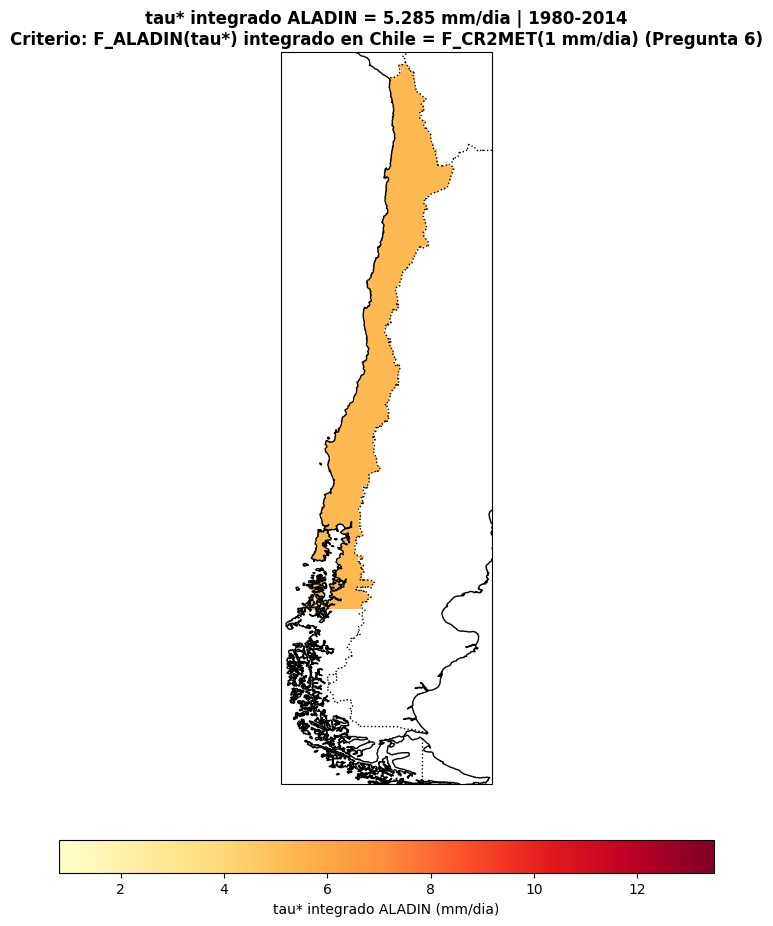

4/5: Mapa de tau* local (Forma C)...


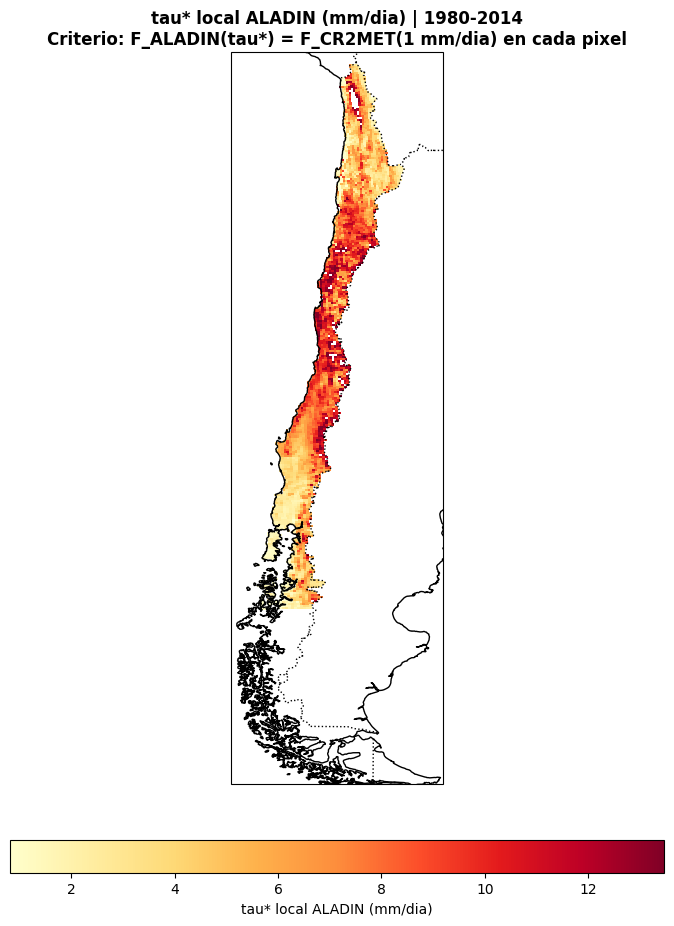

4/5: Mapas — Forma A — Opcion B (tau* integrado)


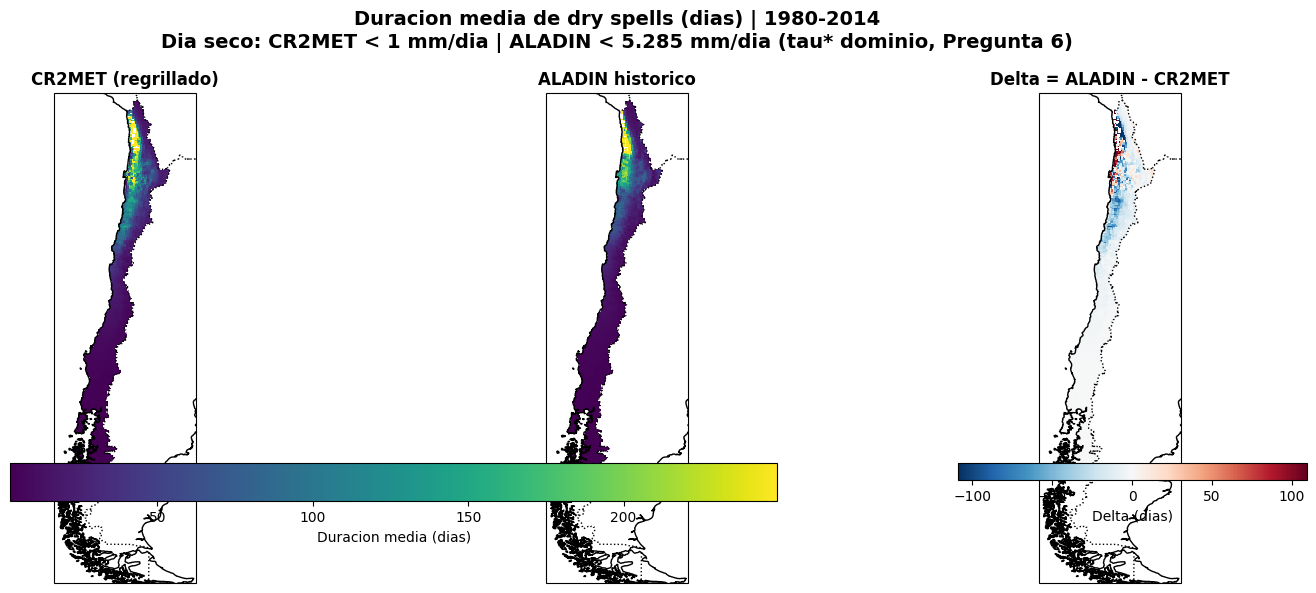

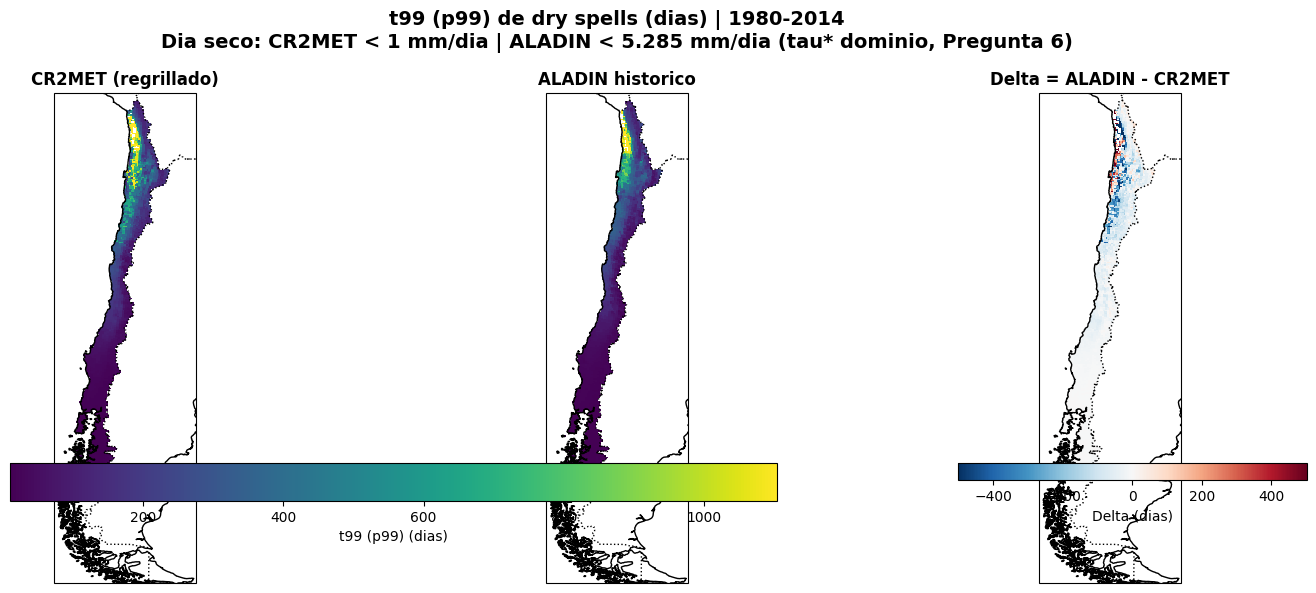

4/5: Mapas — Forma B — Mismo umbral en CR2MET y ALADIN


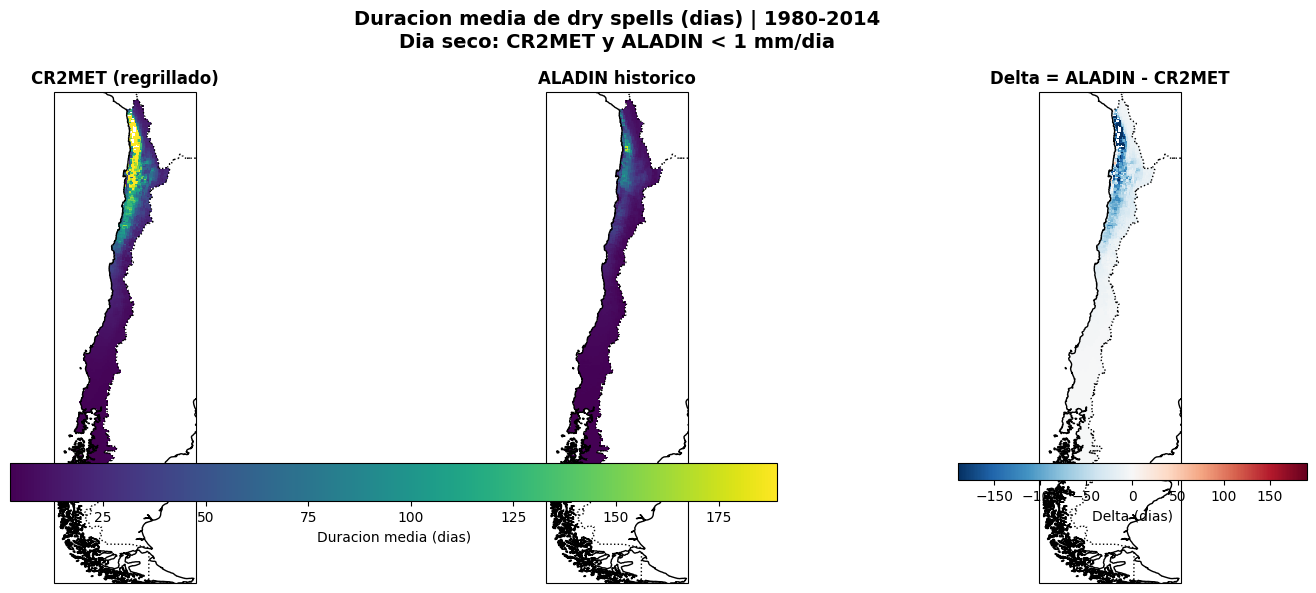

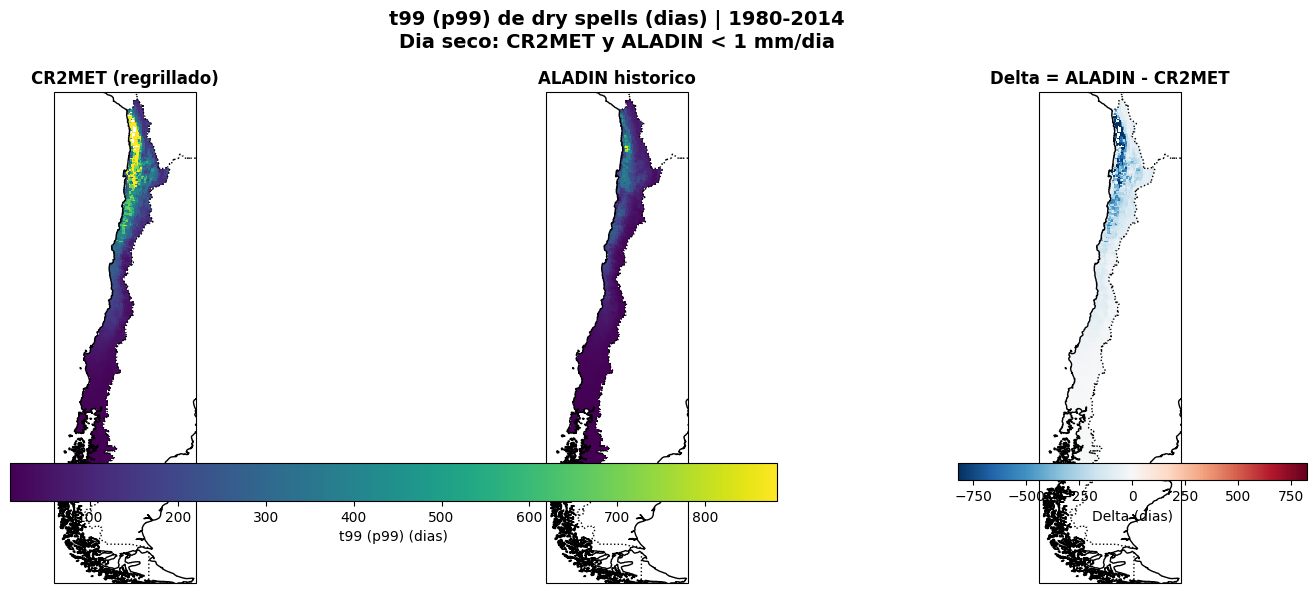

4/5: Mapas — Forma C — tau* local (wet-day matching por pixel)


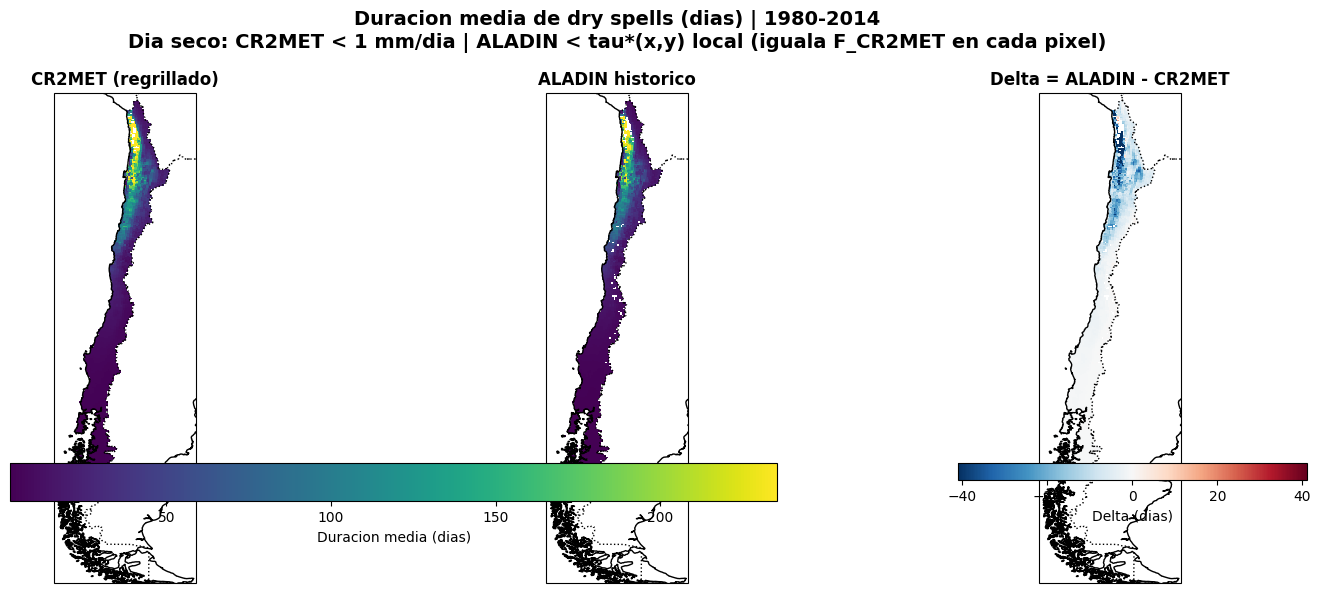

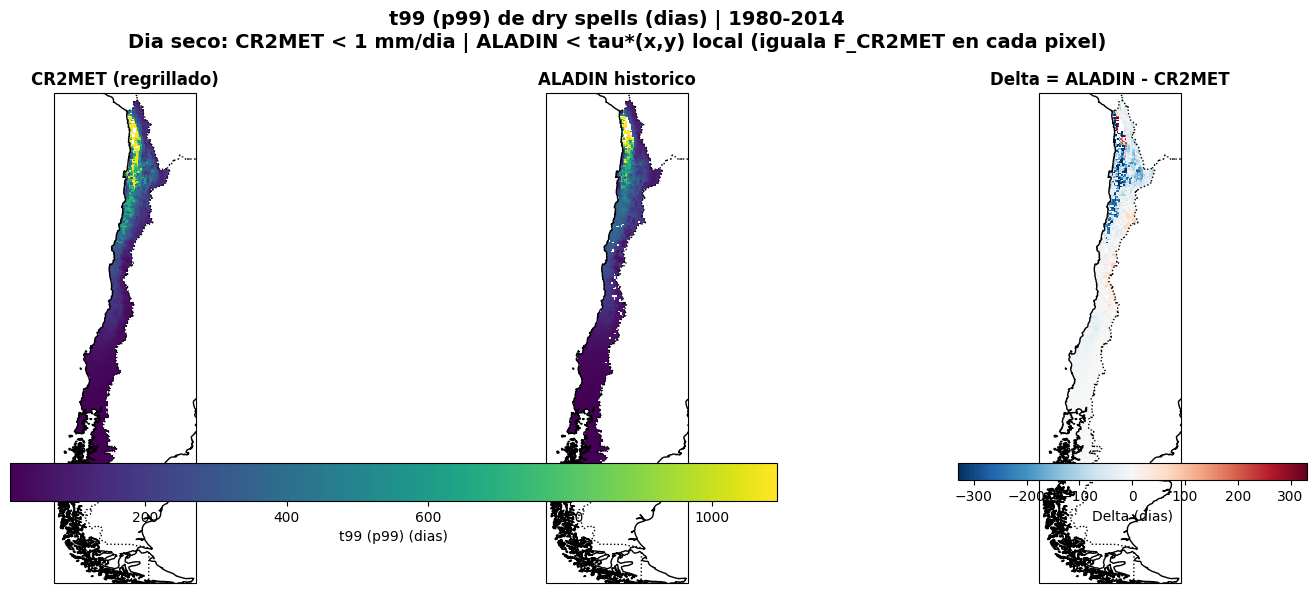

5/5: Resumen numerico (promedios espaciales) por escenario...


,escenario,dataset,metrica,mean_espacial,median_espacial,min,max
0,Forma A — Opcion B (tau* integrado),CR2MET,Duracion media,42.456,17.062,2.371,424.900
1,Forma A — Opcion B (tau* integrado),ALADIN,Duracion media,35.065,12.308,2.455,425.067
2,Forma A — Opcion B (tau* integrado),DELTA (ALADIN-CR2MET),Duracion media,-7.868,-2.181,-337.181,342.850
3,Forma A — Opcion B (tau* integrado),CR2MET,t99 (p99),221.770,133.000,9.000,2561.700
4,Forma A — Opcion B (tau* integrado),ALADIN,t99 (p99),178.183,93.890,9.000,2422.020
5,Forma A — Opcion B (tau* integrado),DELTA (ALADIN-CR2MET),t99 (p99),-44.737,-16.860,-1451.340,2081.020
6,Forma B — Mismo umbral en CR2MET y ALADIN,CR2MET,Duracion media,42.456,17.062,2.371,424.900
7,Forma B — Mismo umbral en CR2MET y ALADIN,ALADIN,Duracion media,15.554,7.795,2.028,178.817
8,Forma B — Mismo umbral en CR2MET y ALADIN,DELTA (ALADIN-CR2MET),Duracion media,-27.468,-8.332,-394.372,52.722
9,Forma B — Mismo umbral en CR2MET y ALADIN,CR2MET,t99 (p99),221.770,133.000,9.000,2561.700


Nota: si COMPUTE_TL=False, no se calcula tL (mas inestable y costosa).


In [3]:
# =====================================================================
# MAPAS: CR2MET / ALADIN / DELTA (+ mapa de tau* local)
# =====================================================================
def plot_three_panel_maps(cr2_da, ala_da, delta_da, *, title, cbar_label, cmap_main='viridis', cmap_delta='RdBu_r', vmin=None, vmax=None, dv=None):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    for ax in axes:
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.set_extent(CHILE_EXTENT)

    cr2_da.plot.pcolormesh(
        ax=axes[0], x='lon', y='lat', transform=ccrs.PlateCarree(), cmap=cmap_main,
        vmin=vmin, vmax=vmax, add_colorbar=False,
    )
    axes[0].set_title('CR2MET (regrillado)', fontweight='bold')

    im1 = ala_da.plot.pcolormesh(
        ax=axes[1], x='lon', y='lat', transform=ccrs.PlateCarree(), cmap=cmap_main,
        vmin=vmin, vmax=vmax, add_colorbar=False,
    )
    axes[1].set_title('ALADIN historico', fontweight='bold')

    if dv is None:
        vals = delta_da.where(chile_mask).values.ravel()
        vals = vals[np.isfinite(vals)]
        dv = float(np.nanpercentile(np.abs(vals), 98)) if vals.size else 1.0
        dv = max(dv, 0.5)

    im2 = delta_da.plot.pcolormesh(
        ax=axes[2], x='lon', y='lat', transform=ccrs.PlateCarree(), cmap=cmap_delta,
        vmin=-dv, vmax=dv, add_colorbar=False,
    )
    axes[2].set_title('Delta = ALADIN - CR2MET', fontweight='bold')

    cbar0 = fig.colorbar(im1, ax=axes[:2].ravel().tolist(), orientation='horizontal', shrink=0.85, pad=0.08)
    cbar0.set_label(cbar_label)
    cbar1 = fig.colorbar(im2, ax=[axes[2]], orientation='horizontal', shrink=0.85, pad=0.08)
    cbar1.set_label('Delta (dias)')

    plt.suptitle(title, fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()


def plot_threshold_map(tau_da, title, *, cbar_label='tau* ALADIN (mm/dia)', vmin=None, vmax=None, save_path=None):
    vals = tau_da.where(chile_mask).values.ravel()
    vals = vals[np.isfinite(vals)]
    if vmin is None:
        vmin = float(np.nanpercentile(vals, 2)) if vals.size else 0.0
    if vmax is None:
        vmax = float(np.nanpercentile(vals, 98)) if vals.size else 8.0

    fig, ax = plt.subplots(figsize=(8, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent(CHILE_EXTENT)

    im = tau_da.plot.pcolormesh(
        ax=ax, x='lon', y='lat', transform=ccrs.PlateCarree(), cmap='YlOrRd',
        vmin=vmin, vmax=vmax, add_colorbar=False,
    )
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', shrink=0.85, pad=0.06)
    cbar.set_label(cbar_label)
    ax.set_title(title, fontweight='bold')
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def summarize_map(da, label):
    vals = da.where(chile_mask).values.ravel()
    vals = vals[np.isfinite(vals)]
    return {
        'metrica': label,
        'mean_espacial': float(np.nanmean(vals)) if vals.size else np.nan,
        'median_espacial': float(np.nanmedian(vals)) if vals.size else np.nan,
        'min': float(np.nanmin(vals)) if vals.size else np.nan,
        'max': float(np.nanmax(vals)) if vals.size else np.nan,
    }


def run_maps_for_scenario(scenario_key):
    cfg = results[scenario_key]['cfg']
    metrics_cr2, metrics_ala, metrics_delta = results[scenario_key]['metrics']

    print(f"4/5: Mapas — {cfg['title']}")
    for key, label in [('mean', 'Duracion media'), ('t99', 't99 (p99)'), ('tL', 'tL (cutoff)')]:
        if key == 'tL' and not COMPUTE_TL:
            continue

        cr2 = metrics_cr2[key]
        ala = metrics_ala[key]
        dlt = metrics_delta[key]

        vals = np.concatenate([
            cr2.where(chile_mask).values.ravel(),
            ala.where(chile_mask).values.ravel(),
        ])
        vals = vals[np.isfinite(vals)]
        if vals.size:
            vmin = float(np.nanpercentile(vals, 2))
            vmax = float(np.nanpercentile(vals, 98))
        else:
            vmin, vmax = None, None

        plot_three_panel_maps(
            cr2, ala, dlt,
            title=(
                f"{label} de dry spells (dias) | {START_DATE[:4]}-{END_DATE[:4]}\n"
                f"{cfg['threshold_note']}"
            ),
            cbar_label=f'{label} (dias)',
            vmin=vmin, vmax=vmax,
        )

    rows = []
    for key, label in [('mean', 'Duracion media'), ('t99', 't99 (p99)'), ('tL', 'tL (cutoff)')]:
        if key == 'tL' and not COMPUTE_TL:
            continue
        rows.append({'escenario': cfg['title'], 'dataset': 'CR2MET', **summarize_map(metrics_cr2[key], label)})
        rows.append({'escenario': cfg['title'], 'dataset': 'ALADIN', **summarize_map(metrics_ala[key], label)})
        rows.append({'escenario': cfg['title'], 'dataset': 'DELTA (ALADIN-CR2MET)', **summarize_map(metrics_delta[key], label)})

    return pd.DataFrame(rows)


import os

# Escala comun para comparar mapas integrado vs local
_vals_tau = tau_local_map.where(chile_mask).values.ravel()
_vals_tau = _vals_tau[np.isfinite(_vals_tau)]
_tau_vmin = float(np.nanpercentile(_vals_tau, 2)) if _vals_tau.size else 0.0
_tau_vmax = float(np.nanpercentile(_vals_tau, 98)) if _vals_tau.size else 8.0

tau_integrado_map = xr.full_like(tau_local_map, TAU_ALADIN_DOMINIO).where(chile_mask)
_tau_out = '_pregunta7_outputs'
os.makedirs(_tau_out, exist_ok=True)

print('4/5: Mapa de tau* integrado (Forma A / Pregunta 6)...')
plot_threshold_map(
    tau_integrado_map,
    title=(
        f'tau* integrado ALADIN = {TAU_ALADIN_DOMINIO:g} mm/dia | {START_DATE[:4]}-{END_DATE[:4]}\n'
        f'Criterio: F_ALADIN(tau*) integrado en Chile = F_CR2MET({TAU_CR2MET_REF:g} mm/dia) (Pregunta 6)'
    ),
    cbar_label='tau* integrado ALADIN (mm/dia)',
    vmin=_tau_vmin,
    vmax=_tau_vmax,
    save_path=os.path.join(_tau_out, 'tau_integrado_map.png'),
)

print('4/5: Mapa de tau* local (Forma C)...')
plot_threshold_map(
    tau_local_map,
    title=(
        f'tau* local ALADIN (mm/dia) | {START_DATE[:4]}-{END_DATE[:4]}\n'
        f'Criterio: F_ALADIN(tau*) = F_CR2MET({TAU_CR2MET_REF:g} mm/dia) en cada pixel'
    ),
    cbar_label='tau* local ALADIN (mm/dia)',
    vmin=_tau_vmin,
    vmax=_tau_vmax,
    save_path=os.path.join(_tau_out, 'tau_local_map.png'),
)

summary_tables = []
for scenario_key in SCENARIOS:
    summary_tables.append(run_maps_for_scenario(scenario_key))

print('5/5: Resumen numerico (promedios espaciales) por escenario...')
summary_df = pd.concat(summary_tables, ignore_index=True)
display(summary_df.round(3))

print('Nota: si COMPUTE_TL=False, no se calcula tL (mas inestable y costosa).')


## Significancia estadística: bootstrap por años (ALADIN − CR2MET)

Para cada píxel, escenario (Formas A/B/C) y métrica (`mean`, `t99`):

1. Se agrupan las duraciones de dry spells por **año de inicio**.
2. Se remuestrean los años con reemplazo (1 000 réplicas; IC95).
3. En cada réplica se reconstruye el pool de spells de los años sorteados y se recalcula la métrica en CR2MET y ALADIN.
4. **Significativo:** IC95 de Δ = ALADIN − CR2MET **no incluye 0** (α = 0,05).

Mismo periodo pareado **1980–2014** que los mapas descriptivos (Pregunta 3-style, pero con métricas de spells).

In [ ]:
# =====================================================================
# BOOTSTRAP POR ANOS — delta ALADIN - CR2MET (por escenario y metrica)
# =====================================================================
BOOTSTRAP_ITER = 1000
RANDOM_SEED = 42
ALPHA = 0.05
BOOTSTRAP_METRICS = [('mean', 'Duracion media'), ('t99', 't99 (p99)')]


def time_to_year(t):
    if hasattr(t, 'year'):
        return int(t.year)
    return int(pd.Timestamp(str(t)[:10]).year)


def years_from_time(time_coord):
    tvals = time_coord.values
    if hasattr(tvals[0], 'year'):
        return np.array([int(t.year) for t in tvals], dtype=int)
    return pd.to_datetime(tvals).year.to_numpy(dtype=int)


def spell_metric_from_durations(durations, metric_name):
    d = np.asarray(durations, dtype=float)
    d = d[np.isfinite(d) & (d > 0)]
    if d.size < MIN_SPELLS_FOR_STATS:
        return np.nan
    if metric_name == 'mean':
        return float(np.mean(d))
    if metric_name == 't99':
        return float(np.percentile(d, 99))
    return np.nan


def extract_spell_groups_by_year(pr_masked, dry_threshold, mask_da):
    """Por celda apilada: dict {ano: array de duraciones de spells que inician ese ano}."""
    is_dry = (pr_masked < dry_threshold).where(mask_da)
    dry_stacked = is_dry.stack(cell=('y', 'x')).transpose('time', 'cell').compute()
    times = dry_stacked['time'].values
    dry_vals = dry_stacked.values
    n_cells = dry_vals.shape[1]
    groups = [{} for _ in range(n_cells)]

    for idx in range(n_cells):
        col = dry_vals[:, idx]
        if not np.any(col):
            continue
        x = np.asarray(col, dtype=np.bool_)
        padded = np.r_[False, x, False]
        dx = np.diff(padded.astype(np.int8))
        starts, ends = np.where(dx == 1)[0], np.where(dx == -1)[0]
        for s, e in zip(starts, ends):
            duration = int(e - s)
            if duration <= 0:
                continue
            year = time_to_year(times[s])
            groups[idx].setdefault(year, []).append(duration)

    for idx in range(n_cells):
        groups[idx] = {y: np.asarray(v, dtype=np.int16) for y, v in groups[idx].items()}

    return groups, dry_stacked


def pool_spells_by_years(group_dict, year_list):
    parts = [group_dict[y] for y in year_list if y in group_dict and group_dict[y].size > 0]
    if not parts:
        return np.array([], dtype=np.int16)
    return np.concatenate(parts)


def bootstrap_one_cell(groups_cr2, groups_ala, years_arr, metric_name, n_iter, rng):
    if not groups_cr2 or not groups_ala:
        return np.nan, np.nan, np.nan, False, False, False

    all_years = [y for y in years_arr if y in groups_cr2 or y in groups_ala]
    if not all_years:
        return np.nan, np.nan, np.nan, False, False, False

    d_cr2 = pool_spells_by_years(groups_cr2, all_years)
    d_ala = pool_spells_by_years(groups_ala, all_years)
    m_cr2 = spell_metric_from_durations(d_cr2, metric_name)
    m_ala = spell_metric_from_durations(d_ala, metric_name)
    if not (np.isfinite(m_cr2) and np.isfinite(m_ala)):
        return np.nan, np.nan, np.nan, False, False, False

    obs_delta = m_ala - m_cr2
    boots = np.empty(n_iter, dtype=np.float64)
    n_years = years_arr.size
    for b in range(n_iter):
        draw = rng.choice(years_arr, size=n_years, replace=True)
        bm_cr2 = spell_metric_from_durations(pool_spells_by_years(groups_cr2, draw), metric_name)
        bm_ala = spell_metric_from_durations(pool_spells_by_years(groups_ala, draw), metric_name)
        boots[b] = bm_ala - bm_cr2 if np.isfinite(bm_cr2) and np.isfinite(bm_ala) else np.nan

    boots = boots[np.isfinite(boots)]
    if boots.size < 50:
        return obs_delta, np.nan, np.nan, False, False, False

    ci_low, ci_high = np.percentile(boots, [100 * ALPHA / 2, 100 * (1 - ALPHA / 2)])
    significant = (ci_low > 0) or (ci_high < 0)
    sig_higher = ci_low > 0
    sig_lower = ci_high < 0
    return obs_delta, ci_low, ci_high, significant, sig_higher, sig_lower


def bootstrap_paired_spell_maps(groups_cr2, groups_ala, cell_template, years_arr, metric_name,
                                n_iter=BOOTSTRAP_ITER, seed=RANDOM_SEED):
    n_cells = len(groups_cr2)
    rng = np.random.default_rng(seed)
    obs = np.full(n_cells, np.nan, dtype=np.float64)
    ci_low = np.full(n_cells, np.nan, dtype=np.float64)
    ci_high = np.full(n_cells, np.nan, dtype=np.float64)
    significant = np.zeros(n_cells, dtype=bool)
    sig_higher = np.zeros(n_cells, dtype=bool)
    sig_lower = np.zeros(n_cells, dtype=bool)

    for idx in range(n_cells):
        if idx > 0 and idx % 500 == 0:
            print(f'      celda {idx}/{n_cells}...')
        obs[idx], ci_low[idx], ci_high[idx], significant[idx], sig_higher[idx], sig_lower[idx] = (
            bootstrap_one_cell(groups_cr2[idx], groups_ala[idx], years_arr, metric_name, n_iter, rng)
        )

    def _to_da(arr, name):
        da_1d = xr.DataArray(arr, coords={'cell': cell_template['cell']}, dims=['cell'], name=name)
        da_2d = da_1d.unstack('cell')
        return da_2d.assign_coords(lat=chile_mask['lat'], lon=chile_mask['lon'])

    return {
        'mean_diff': _to_da(obs, 'mean_diff'),
        'ci_low': _to_da(ci_low, 'ci_low'),
        'ci_high': _to_da(ci_high, 'ci_high'),
        'significant': _to_da(significant.astype(np.float32), 'significant'),
        'sig_higher': _to_da(sig_higher.astype(np.float32), 'sig_higher'),
        'sig_lower': _to_da(sig_lower.astype(np.float32), 'sig_lower'),
    }


def summarize_bootstrap_spell_map(diff_da, sig_da, sig_higher_da, escenario, metric_label):
    data = diff_da.where(chile_mask).values.ravel()
    sig = sig_da.where(chile_mask).values.ravel().astype(bool)
    sig_hi = sig_higher_da.where(chile_mask).values.ravel().astype(bool)
    valid = np.isfinite(data)
    data, sig, sig_hi = data[valid], sig[valid], sig_hi[valid]
    return {
        'Escenario': escenario,
        'Metrica': metric_label,
        'Delta medio espacial (dias)': float(np.mean(data)) if data.size else np.nan,
        'Delta mediano espacial (dias)': float(np.median(data)) if data.size else np.nan,
        '% celdas significativas': float(np.mean(sig) * 100.0) if sig.size else np.nan,
        '% ALADIN > CR2MET (sig.)': float(np.mean(sig_hi) * 100.0) if sig_hi.size else np.nan,
        '% ALADIN < CR2MET (sig.)': float(np.mean(sig & ~sig_hi) * 100.0) if sig.size else np.nan,
        'Celdas validas': int(data.size),
    }


def plot_bootstrap_delta_map(diff_da, significant_da, *, title, cbar_label='Delta (dias)'):
    vals = diff_da.where(chile_mask).values.ravel()
    vals = vals[np.isfinite(vals)]
    lim = float(np.nanpercentile(np.abs(vals), 98)) if vals.size else 1.0
    lim = max(lim, 0.5)

    fig, ax = plt.subplots(figsize=(8.5, 6.5), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent(CHILE_EXTENT)

    im = diff_da.plot.pcolormesh(
        ax=ax, x='lon', y='lat', transform=ccrs.PlateCarree(), cmap='RdBu',
        vmin=-lim, vmax=lim, add_colorbar=False,
    )
    sig_mask = xr.where(significant_da > 0.5, 1.0, np.nan)
    ax.contourf(
        diff_da['lon'], diff_da['lat'], sig_mask,
        levels=[0.5, 1.5], colors='none', hatches=['....'], transform=ccrs.PlateCarree(),
    )
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', shrink=0.8, pad=0.07)
    cbar.set_label(cbar_label)
    ax.set_title(title, fontweight='bold')
    plt.tight_layout()
    plt.show()


YEARS_COMMON = np.unique(years_from_time(pr_aladin_chile['time']))
N_YEARS_COMMON = int(YEARS_COMMON.size)

print('6/6: Bootstrap por anos para significancia (ALADIN - CR2MET)...')
print(f'  Anos: {N_YEARS_COMMON} | iteraciones: {BOOTSTRAP_ITER} | IC95% | metricas: mean, t99')

bootstrap_results = {}
bootstrap_summary_rows = []

for scen_key, cfg in SCENARIOS.items():
    print(f"\n  Escenario: {cfg['title']}")
    groups_cr2, cell_tpl = extract_spell_groups_by_year(
        pr_cr2met_chile, cfg['thresh_cr2'], chile_mask,
    )
    groups_ala, _ = extract_spell_groups_by_year(
        pr_aladin_chile, cfg['thresh_ala'], chile_mask,
    )
    bootstrap_results[scen_key] = {}

    for metric_key, metric_label in BOOTSTRAP_METRICS:
        print(f'    Bootstrap: {metric_label}...')
        res = bootstrap_paired_spell_maps(
            groups_cr2, groups_ala, cell_tpl, YEARS_COMMON, metric_key,
            n_iter=BOOTSTRAP_ITER, seed=RANDOM_SEED,
        )
        bootstrap_results[scen_key][metric_key] = res
        bootstrap_summary_rows.append(
            summarize_bootstrap_spell_map(
                res['mean_diff'], res['significant'], res['sig_higher'],
                cfg['title'], metric_label,
            )
        )

bootstrap_summary = pd.DataFrame(bootstrap_summary_rows)
display(bootstrap_summary.round(3))

print('\nMapas delta con hachurado (significativo) — Forma A, duracion media:')
res_a_mean = bootstrap_results['A_opcion_B_integrado']['mean']
plot_bootstrap_delta_map(
    res_a_mean['mean_diff'], res_a_mean['significant'],
    title=(
        f"Delta duracion media dry spells | Forma A (tau* integrado)\n"
        f"IC95 bootstrap por ano (n={BOOTSTRAP_ITER}) | hachurado: significativo"
    ),
)

print('\n=== Lectura rapida bootstrap ===')
for _, row in bootstrap_summary.iterrows():
    print(
        f"- [{row['Escenario'][:20]}...] {row['Metrica']}: "
        f"delta medio {row['Delta medio espacial (dias)']:.2f} dias | "
        f"{row['% celdas significativas']:.1f}% celdas significativas | "
        f"ALADIN > CR2MET (sig.) en {row['% ALADIN > CR2MET (sig.)']:.1f}%"
    )
print(
    f"\nNota: bootstrap usa {N_YEARS_COMMON} anos ({START_DATE[:4]}-{END_DATE[:4]}); "
    f'remuestreo por ano de inicio de spell.'
)

6/6: Bootstrap por anos para significancia (ALADIN - CR2MET)...
  Anos: 35 | iteraciones: 1000 | IC95% | metricas: mean, t99

  Escenario: Forma A — Opcion B (tau* integrado)
    Bootstrap: Duracion media...
      celda 500/17340...
      celda 1000/17340...
      celda 1500/17340...
      celda 2000/17340...
      celda 2500/17340...
      celda 3000/17340...
      celda 3500/17340...
      celda 4000/17340...
      celda 4500/17340...
      celda 5000/17340...
      celda 5500/17340...
      celda 6000/17340...
      celda 6500/17340...
      celda 7000/17340...
      celda 7500/17340...
      celda 8000/17340...
      celda 8500/17340...
      celda 9000/17340...
      celda 9500/17340...
      celda 10000/17340...
      celda 10500/17340...
      celda 11000/17340...
      celda 11500/17340...
      celda 12000/17340...
      celda 12500/17340...
      celda 13000/17340...
      celda 13500/17340...
      celda 14000/17340...
      celda 14500/17340...
      celda 15000/17340...
  

## Conclusiones (bootstrap) — dry spells CR2MET vs ALADIN, 1980–2014

| Escenario | Métrica | Δ medio (días) | % celdas sig. | % ALADIN > CR2MET (sig.) | % ALADIN < CR2MET (sig.) |
|---|---|---|---|---|---|
| Forma A (Ro integrado) | Duración media | **−7,9** | **72,9 %** | 7,6 % | **65,3 %** |
| Forma A (Ro integrado) | t99 | **−44,7** | 46,6 % | 3,6 % | 43,0 % |
| Forma B (Ro = 1 mm) | Duración media | **−27,5** | **98,1 %** | 0,5 % | **97,6 %** |
| Forma B (Ro = 1 mm) | t99 | **−135,4** | **93,1 %** | 0,2 % | **92,9 %** |
| Forma C (Ro local) | Duración media | **−6,7** | 49,1 % | 0,2 % | 48,9 % |
| Forma C (Ro local) | t99 | **−35,3** | 30,3 % | 4,4 % | 25,9 % |

*(Δ = ALADIN − CR2MET; negativo ⇒ spells más cortos en ALADIN. Bootstrap: 1 000 réplicas, remuestreo por año de inicio de spell, IC95.)*

1. **Forma B (sin calibración):** el sesgo es **masivo y casi universal** — en ~98 % de Chile, ALADIN tiene dry spells **significativamente más cortos** que CR2MET (coherente con P3: ALADIN más húmedo con τ = 1 mm fragmenta las rachas).
2. **Forma A (τ* integrado):** calibrar wet days **reduce** el sesgo (Δ de −27,5 → −7,9 días en media), pero en **~73 %** de celdas la diferencia sigue siendo significativa; ALADIN aún tiene spells más cortos en **~65 %** del territorio.
3. **Forma C (τ* local):** la calibración pixel a pixel **homogeneiza más** — solo **~49 %** de celdas significativas en duración media; el sesgo residual baja a −6,7 días de media. La cola (t99) es menos robusta (~30 % sig.).
4. **Media vs cola:** el sesgo en spells extremos (t99) es mayor en magnitud y algo menos universalmente significativo tras calibración; la cola es más sensible al muestreo interanual.
5. **Interpretación:** igualar wet days (A o C) **no elimina** por completo las diferencias en duración de dry spells; queda sesgo estructural en cómo cada producto representa la persistencia de la sequedad. Para comparaciones ALADIN–CR2MET conviene **τ* calibrado** (A o C), no τ = 1 mm en ambos.